# 1. Importazione delle librerie

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, Activation
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Configurazioni grafiche
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

# 2. Generazione e analisi del dataset (EDA)

generazione del dataset con 100 variabili, di cui solo 15 con impatto reale sul target e aggiungiamo un noise = 25 

In [3]:
X, y = make_regression(
        n_samples=6000, 
        n_features=100, 
        n_informative=15, 
        noise=25.0,
        random_state=42
    )
    
# Normalizziamo il target per una convergenza più rapida
y = (y - y.mean()) / y.std()

feature_names = [f'Feat_{i}' for i in range(100)]
df = pd.DataFrame(X, columns=feature_names)
df['Target'] = y

print(f"Dimensioni del Dataset: {df.shape}")
display(df.iloc[:, :10].describe()) # Mostriamo solo le prime 10 feature per brevità"

Dimensioni del Dataset: (6000, 101)


,Feat_0,Feat_1,Feat_2,Feat_3,Feat_4,Feat_5,Feat_6,Feat_7,Feat_8,Feat_9
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,0.002112,-0.001749,-0.005200,-0.000749,0.014843,0.032045,-0.034638,-0.015766,-0.015211,0.005868
std,0.982843,1.011354,1.003088,0.997920,1.004975,1.002629,1.003460,1.013533,1.009901,0.990961
min,-3.347473,-3.453354,-3.729174,-3.856375,-3.604870,-3.426983,-4.374043,-3.616800,-3.587377,-3.436062
25%,-0.671431,-0.668450,-0.681344,-0.675612,-0.656688,-0.643845,-0.714116,-0.692835,-0.710187,-0.673598
50%,0.014702,0.004162,-0.007745,-0.023095,0.021079,0.035526,-0.040139,-0.010329,-0.009950,0.013973
75%,0.657554,0.661882,0.687487,0.675254,0.688718,0.698818,0.654094,0.667209,0.667244,0.665098
max,3.609479,3.383526,3.766234,4.202026,3.671569,3.650444,3.703406,3.627253,3.548682,3.520649


Visualizzazione delle Correlazioni per verificare quali hanno correlazione con il target: sono queste quelle su cui verrà applicato il rumore

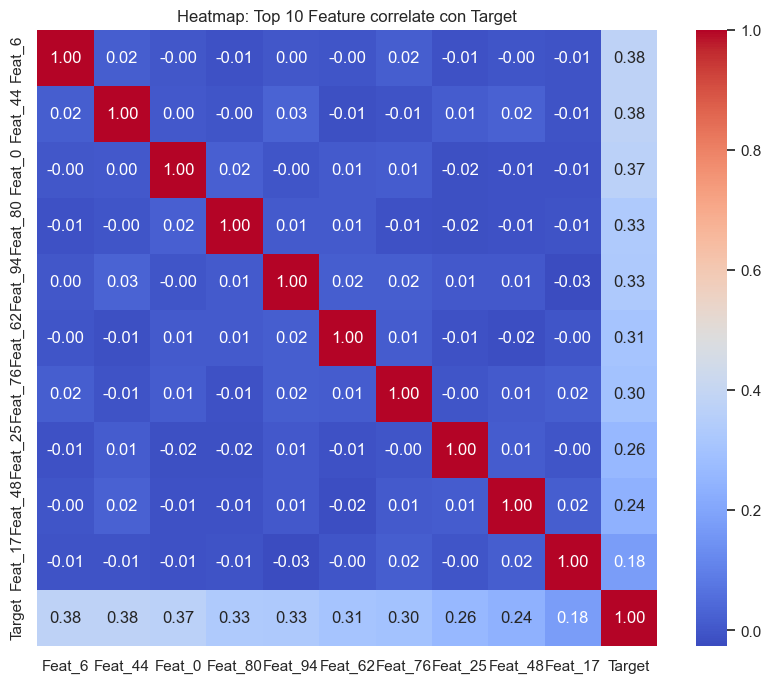

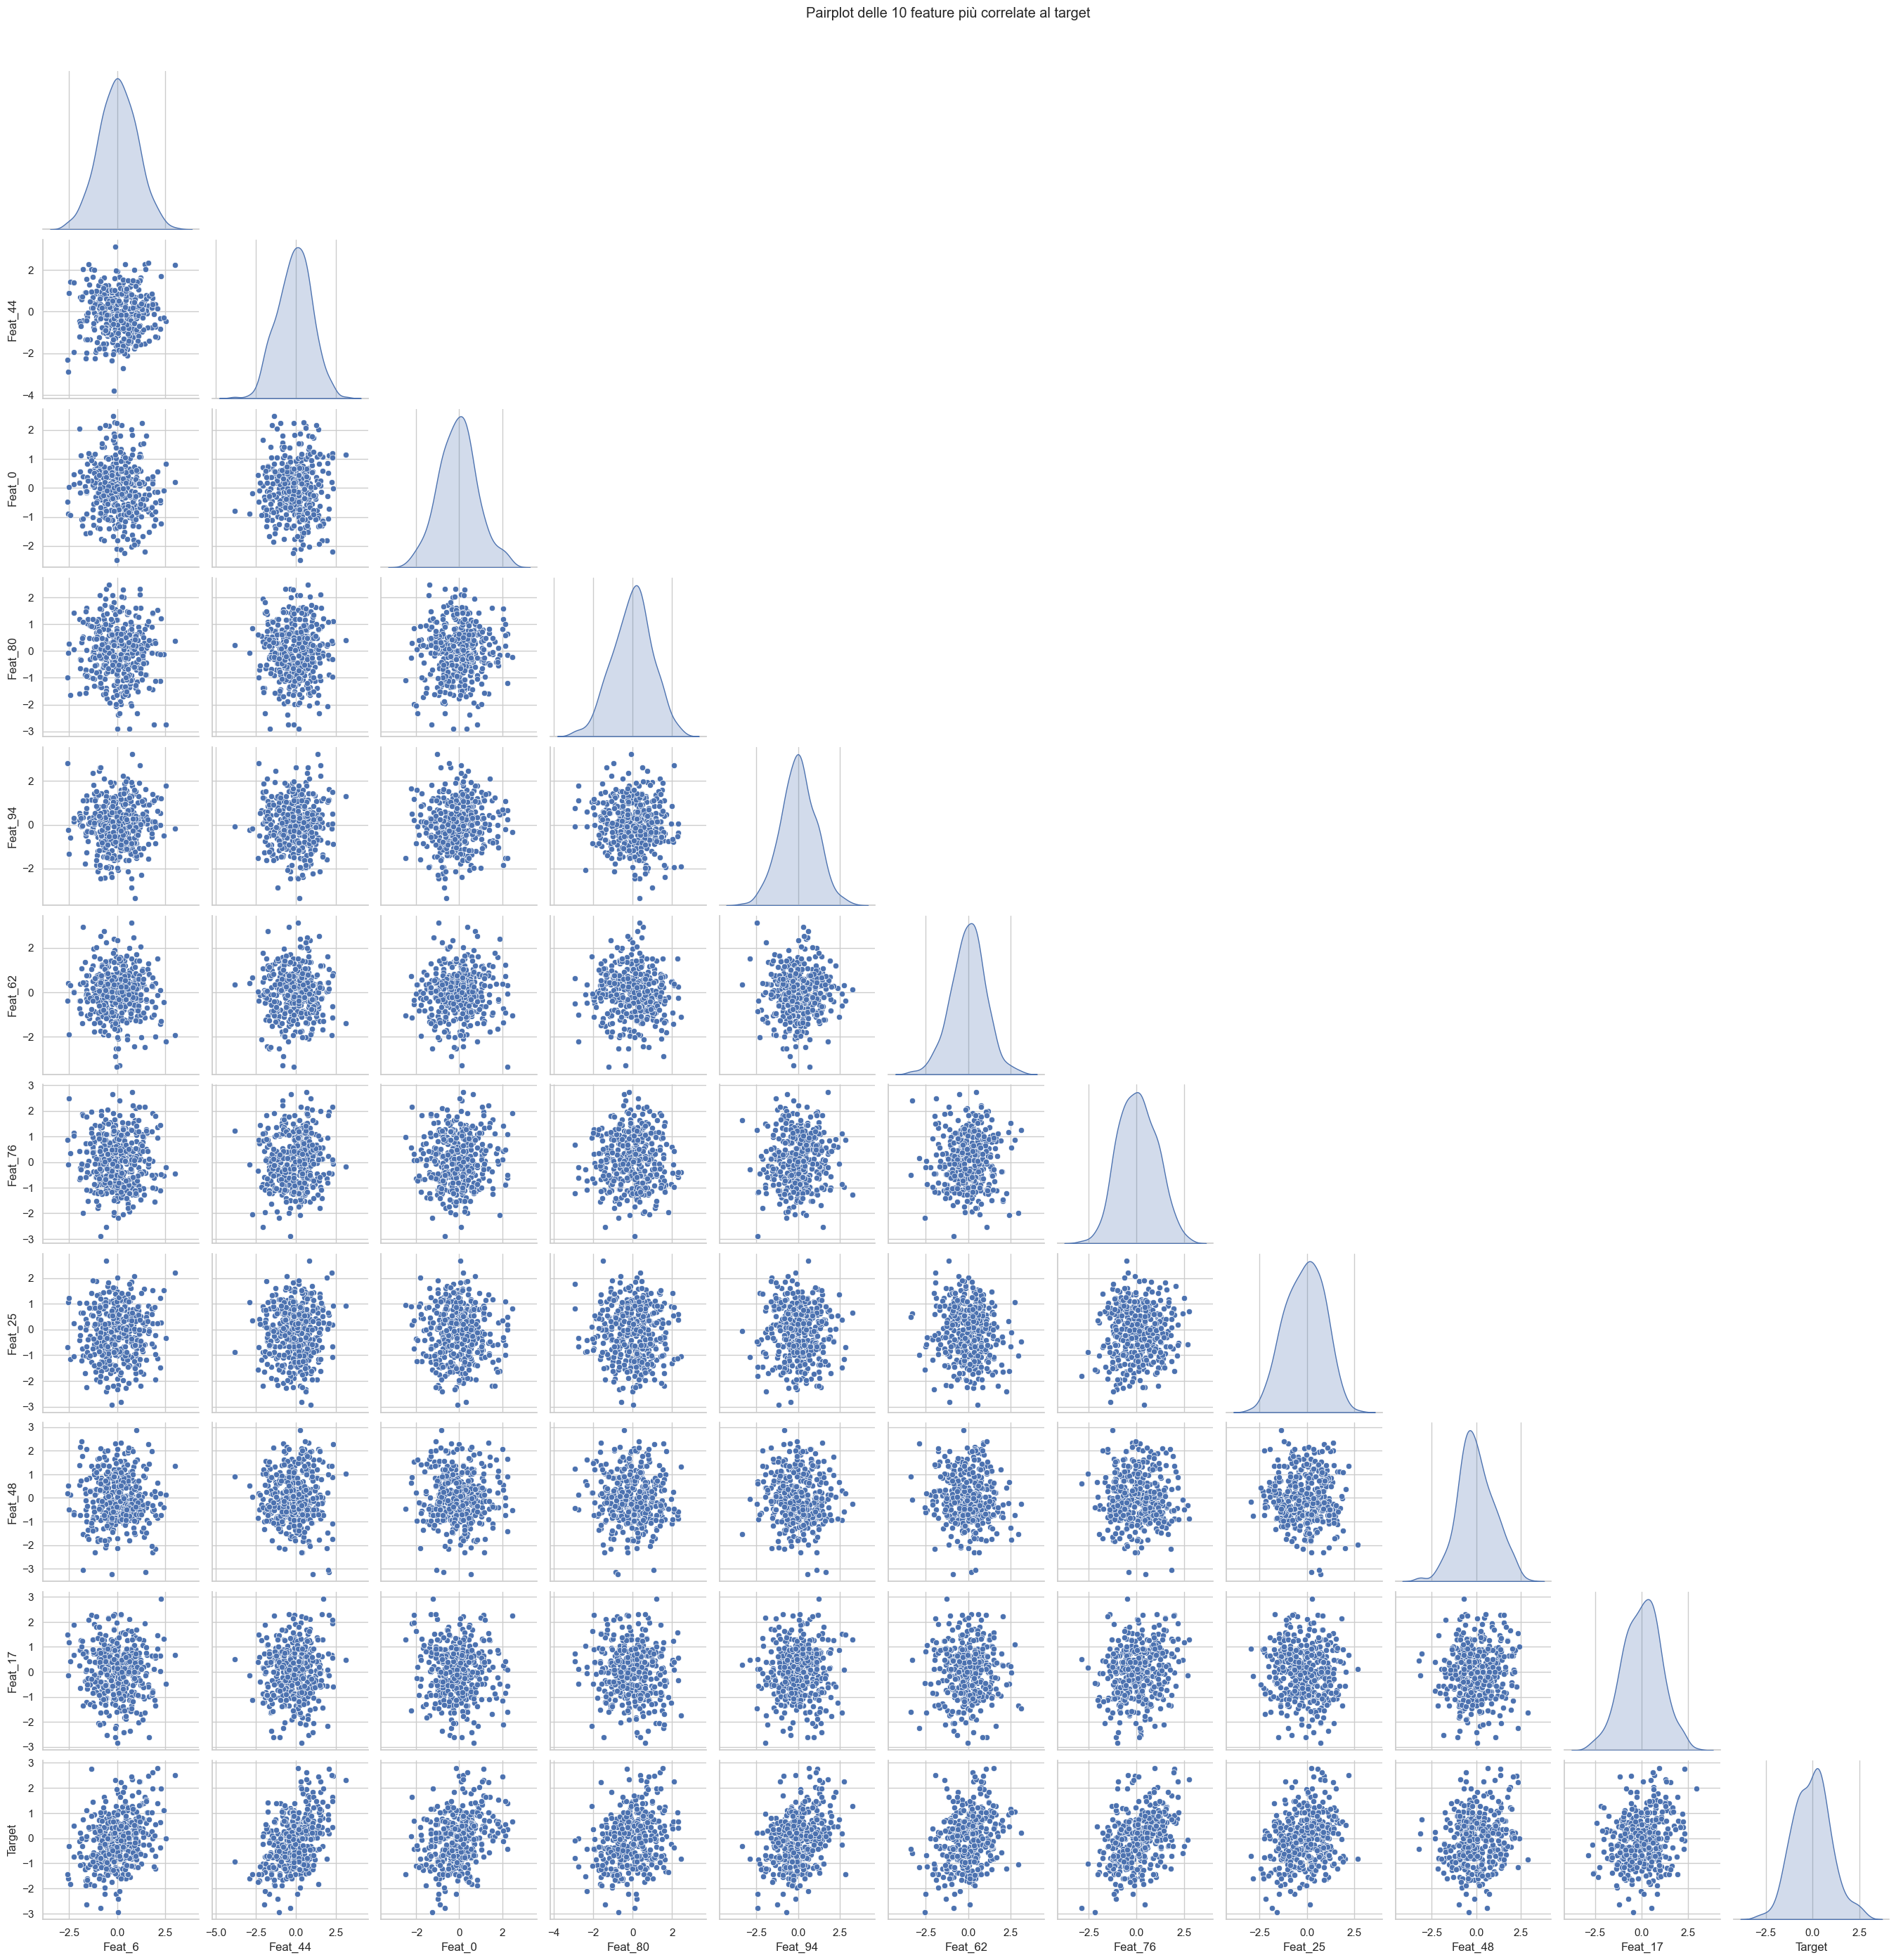

In [5]:
# 1. Calcolo della correlazione rispetto al target con l'assunzione che l'ulteriore colonna sia il targegt 
target_col = df.columns[-1]
correlations = df.corr()[target_col].abs().sort_values(ascending=False)

# 2. Selezione delle prime 10 feature (escludendo il target)
top_10_features = correlations.iloc[1:11].index.to_list()

# Creazione di una lista che include anche il target per i grafici
cols_to_plot = top_10_features + [target_col]

# --- HEATMAP ----
plt.figure(figsize=(10,8))
sns.heatmap(df[cols_to_plot].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title(f"Heatmap: Top 10 Feature correlate con {target_col}")
plt.show()

# --- PAIRPLOT ----
# con campione di 400 righe per visualizzare il rendering

sns.pairplot(df.sample(min(400, len(df)))[cols_to_plot], diag_kind="kde", corner=True)
plt.suptitle(f"Pairplot delle 10 feature più correlate al target", y=1.02)
plt.show()

# 3. Preprocessing e Data Split

In [6]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Set di addestramento: {X_train.shape}")
print(f"Set di validazione: {X_val.shape}")

Set di addestramento: (3360, 100)
Set di validazione: (840, 100)


# 4. Architettura dei modelli

Il modello Robust utilizza:
- ELU Activation per prevenire la morte dei neuroni;
- Batch Normalization per stabilizzare il gradiente;
- L2 Regularization per forzare i pesi delle feature inutili verso lo 0;
- Dropout per prevenire la co-dipendenza tra i neuroni

In [11]:
def build_baseline_model():
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense (256, activation="relu"),
        Dense (128, activation="relu"),
        Dense (1)
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

def build_robust_model():
    model = Sequential([
        Input(shape=(X_train.shape[1],)),

        Dense (256, kernel_regularizer=regularizers.l2(1e-4)),
        BatchNormalization(),
        Activation("relu"),
        Dropout(0.2),

        Dense (128, kernel_regularizer=regularizers.l2(1e-4)),
        BatchNormalization(),
        Activation("relu"),
        Dropout(0.1),

        Dense (1)
    ])
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
    return model    

# 5. Training  Session con Callback Strategici

In [12]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

print("Addestramento Modello Baseline...")
model_b = build_baseline_model()
history_b = model_b.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=100, batch_size=64, verbose=0)

print("\nAddestramento Modello Robusto...")
model_r = build_robust_model()
history_r = model_r.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=100, batch_size=64, verbose=1, callbacks=callbacks)

Addestramento Modello Baseline...

Addestramento Modello Robusto...
Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7161 - mae: 0.6492 - val_loss: 0.3064 - val_mae: 0.4075 - learning_rate: 0.0010
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3788 - mae: 0.4661 - val_loss: 0.2373 - val_mae: 0.3491 - learning_rate: 0.0010
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2820 - mae: 0.3974 - val_loss: 0.1834 - val_mae: 0.3054 - learning_rate: 0.0010
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2393 - mae: 0.3652 - val_loss: 0.1443 - val_mae: 0.2634 - learning_rate: 0.0010
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2147 - mae: 0.3423 - val_loss: 0.1190 - val_mae: 0.2328 - learning_rate: 0.0010
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1770 - mae: 0.3049 - val_loss: 0.0985 - val_mae: 0.2064 - learning_rate: 0.0010
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1603 - mae: 0.2871 - val_

# 6. Confronto delle permormance

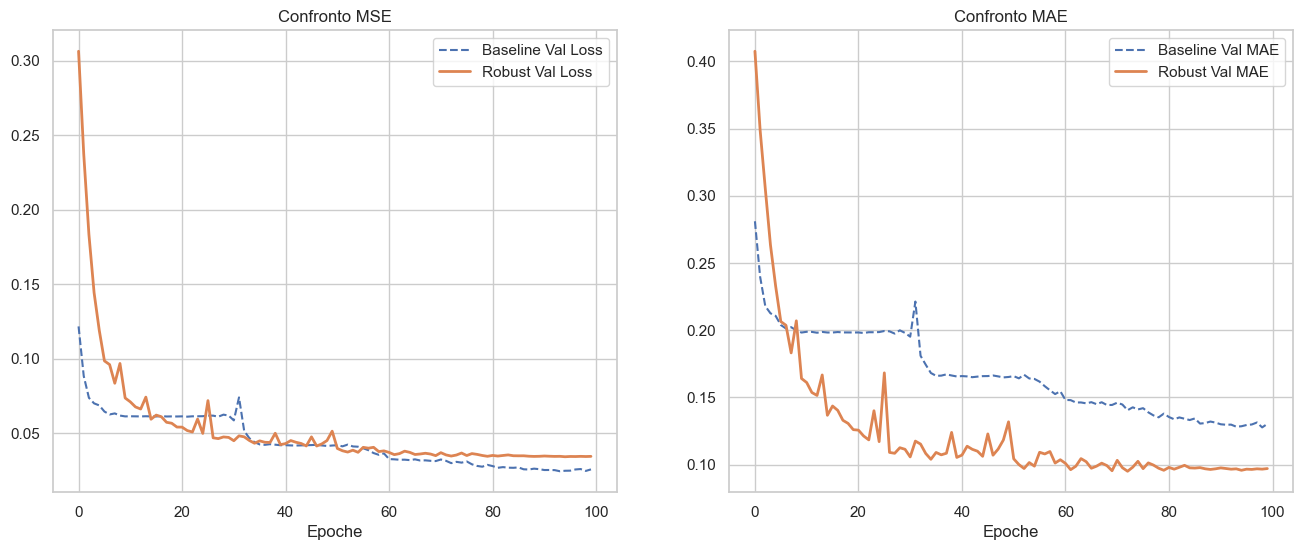

,Modello,MSE (test),MAE (test)
0,Baseline,0.023413,0.121408
1,Robust,0.034474,0.097304


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# plot Loss
ax1.plot(history_b.history["val_loss"], label = "Baseline Val Loss", linestyle = "--")
ax1.plot(history_r.history["val_loss"], label = "Robust Val Loss", linewidth=2)
ax1.set_title("Confronto MSE")
ax1.set_xlabel("Epoche")
ax1.legend()

# plot MAE
ax2.plot(history_b.history["val_mae"], label = "Baseline Val MAE", linestyle = "--")
ax2.plot(history_r.history["val_mae"], label = "Robust Val MAE", linewidth=2)
ax2.set_title("Confronto MAE")
ax2.set_xlabel("Epoche")
ax2.legend()
plt.show()

# Valutazione finale
mse_b, mae_b = model_b.evaluate(X_test, y_test, verbose=0)
mse_r, mae_r = model_r.evaluate(X_test, y_test, verbose=0)

perf_df = pd.DataFrame({
    "Modello": ["Baseline", "Robust"],
    "MSE (test)": [mse_b, mse_r],
    "MAE (test)": [mae_b, mae_r]
})

display(perf_df)